In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.6 MB/s eta 0:00:00


In [ ]:
!pip install joblib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import re
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import joblib

In [ ]:
df = pd.read_csv('/content/data_transaksi_advanced.csv')
df.head()

,id_transaksi,tanggal,waktu,nominal,tipe,kategori,deskripsi,metode_pembayaran,lokasi,user_id,profil,rating,anomaly_flag
0,TRX000001,2022-04-10,15:38,2.067600e+05,keluar,Makanan,Dessert di KFC,e-Wallet,Tangerang,U001,student,5.0,0
1,TRX000002,2023-12-02,11:42,1.261342e+06,masuk,Gaji,Gaji bulanan - student,Tunai,Palembang,U001,student,NaN,0
2,TRX000003,2023-10-10,16:41,3.035182e+06,masuk,Freelance,Jasa foto,Transfer Bank,Medan,U001,student,NaN,0
3,TRX000004,2023-10-06,18:46,4.627192e+06,masuk,Gaji,Lembur,Tunai,Batam,U001,student,NaN,0
4,TRX000005,2022-09-20,19:37,2.080000e+04,keluar,Makanan,Makan siang di Nike Store,Transfer Bank,Surabaya,U001,student,4.0,0


In [ ]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6703 entries, 0 to 6702
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_transaksi       6703 non-null   object 
 1   tanggal            6703 non-null   object 
 2   waktu              6703 non-null   object 
 3   nominal            6703 non-null   float64
 4   tipe               6703 non-null   object 
 5   kategori           6703 non-null   object 
 6   deskripsi          6703 non-null   object 
 7   metode_pembayaran  6703 non-null   object 
 8   lokasi             6703 non-null   object 
 9   user_id            6703 non-null   object 
 10  profil             6703 non-null   object 
 11  rating             4766 non-null   float64
 12  anomaly_flag       6703 non-null   int64  
dtypes: float64(2), int64(1), object(10)
memory usage: 680.9+ KB
None
id_transaksi            0
tanggal                 0
waktu                   0
nominal                 0

In [ ]:
# Drop Kolom yang Tidak Dipakai

df.drop(columns=['rating', 'anomaly_flag', 'id_transaksi', 'user_id'], inplace=True)

In [ ]:
# Ubah Tanggal & Waktu ke Format Numerik

df['tanggal'] = pd.to_datetime(df['tanggal'])
df['bulan'] = df['tanggal'].dt.month
df['hari'] = df['tanggal'].dt.day
df['hari_ke'] = df['tanggal'].dt.dayofweek

df['jam'] = pd.to_datetime(df['waktu'], format='%H:%M').dt.hour

df.drop(columns=['tanggal', 'waktu'], inplace=True)

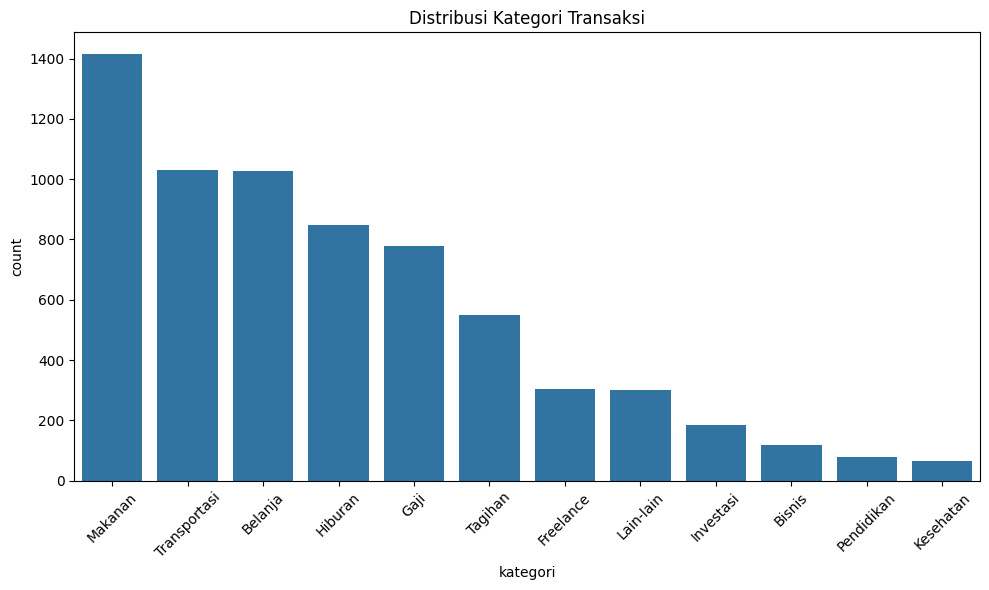

In [ ]:
# Distribusi Kategori Transaksi (Target)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='kategori', order=df['kategori'].value_counts().index)
plt.title('Distribusi Kategori Transaksi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
kategori_counts = df['kategori'].value_counts()
for kategori, jumlah in kategori_counts.items():
    print(f"{kategori:<15}: {jumlah} transaksi")

Makanan        : 1416 transaksi
Transportasi   : 1029 transaksi
Belanja        : 1026 transaksi
Hiburan        : 848 transaksi
Gaji           : 778 transaksi
Tagihan        : 549 transaksi
Freelance      : 305 transaksi
Lain-lain      : 300 transaksi
Investasi      : 185 transaksi
Bisnis         : 120 transaksi
Pendidikan     : 80 transaksi
Kesehatan      : 67 transaksi


In [ ]:
# Stop words bahasa Indonesia
stop_words_indo = [
    'yang', 'dan', 'di', 'ke', 'dari', 'pada', 'untuk', 'dengan', 'sebagai', 'adalah',
    'ini', 'itu', 'karena', 'juga', 'dalam', 'atau', 'sudah', 'belum', 'akan', 'mereka',
    'kami', 'kita', 'saya', 'aku', 'engkau', 'anda', 'dia', 'hingga', 'lebih', 'kurang',
    'setelah', 'sebelum', 'bisa', 'dapat', 'tidak', 'ya', 'hanya', 'masih', 'lagi', 'lewat'
]

# Fungsi preprocessing teks
def clean_text(text):

    # Lowercase dan hapus tanda baca & angka
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)

    # Tokenisasi dan hapus stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words_indo]

    # Normalisasi istilah
    normalisasi = {
        'reksadana': 'investasi',
        'bibit': 'investasi',
        'investree': 'investasi',
        'saham': 'investasi',
        'tabungan': 'investasi',
        'usaha': 'bisnis',
        'toko': 'bisnis',
        'operasional': 'bisnis',
        'spotify': 'tagihan',
        'langganan': 'tagihan',
        'listrik': 'tagihan',
        'air': 'tagihan',
        'pulsa': 'tagihan',
        'internet': 'tagihan',
        'tv': 'tagihan',
        'kabel': 'tagihan',
        'ojek': 'transportasi',
        'gojek': 'transportasi',
        'grab': 'transportasi',
        'mrt': 'transportasi',
        'krl': 'transportasi',
        'busway': 'transportasi',
        'transportasi': 'transportasi',
        'umum': 'transportasi',
        'buku': 'pendidikan',
        'kursus': 'pendidikan',
        'belajar': 'pendidikan',
        'spp': 'pendidikan',
        'gaji': 'gaji',
        'bonus': 'gaji',
        'freelance': 'freelance',
        'honor': 'freelance',
        'makan': 'makanan',
        'makanan': 'makanan',
        'nasi': 'makanan',
        'goreng': 'makanan',
        'sarapan': 'makanan',
        'warteg': 'makanan',
        'warung': 'makanan',
        'restoran': 'makanan',
        'gofood': 'makanan',
        'shopeefood': 'makanan',
        'belanja': 'belanja',
        'baju': 'belanja',
        'sepatu': 'belanja',
        'mall': 'belanja',
        'tokopedia': 'belanja',
        'shopee': 'belanja',
        'tiket': 'hiburan',
        'bioskop': 'hiburan',
        'film': 'hiburan',
        'netflix': 'hiburan',
        'game': 'hiburan',
        'obat': 'kesehatan',
        'apotek': 'kesehatan',
        'rs': 'kesehatan',
        'dokter': 'kesehatan',
        'bca': 'lainlain',
        'bni': 'lainlain',
        'mandiri': 'lainlain',
        'hadiah': 'lainlain',
        'donasi': 'lainlain'
    }

    # Normalisasi token
    tokens = [normalisasi.get(t, t) for t in tokens]

    # Gabungkan kembali
    text = ' '.join(tokens)

    return text


In [ ]:
# Terapkan fungsi clean_text ke data
df['deskripsi_bersih'] = df['deskripsi'].apply(clean_text)

# Fitur dan label
X_text = df['deskripsi_bersih']
y_label = df['kategori']

In [ ]:
# TF-IDF dengan unigram + bigram, tanpa .toarray() untuk efisiensi
vectorizer = TfidfVectorizer(
    max_features=2000,
    stop_words=stop_words_indo,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)
X = vectorizer.fit_transform(X_text)

# Encode label kategori
le = LabelEncoder()
y = le.fit_transform(y_label)

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# SMOTE hanya untuk data train saja
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
# Training model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_res, y_train_res)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
# Cek distribusi data setelah SMOTE
unique, counts = np.unique(y_train_res, return_counts=True)
for label, count in zip(le.inverse_transform(unique), counts):
    print(f"{label:<15}: {count} sampel")

Belanja        : 1133 sampel
Bisnis         : 1133 sampel
Freelance      : 1133 sampel
Gaji           : 1133 sampel
Hiburan        : 1133 sampel
Investasi      : 1133 sampel
Kesehatan      : 1133 sampel
Lain-lain      : 1133 sampel
Makanan        : 1133 sampel
Pendidikan     : 1133 sampel
Tagihan        : 1133 sampel
Transportasi   : 1133 sampel


In [ ]:
# Prediksi
y_pred = model.predict(X_test)

=== Laporan Klasifikasi ===
              precision    recall  f1-score   support

     Belanja       0.98      0.98      0.98       205
      Bisnis       1.00      1.00      1.00        24
   Freelance       1.00      1.00      1.00        61
        Gaji       1.00      1.00      1.00       156
     Hiburan       0.99      0.98      0.99       170
   Investasi       1.00      1.00      1.00        37
   Kesehatan       1.00      0.92      0.96        13
   Lain-lain       0.91      0.98      0.94        60
     Makanan       0.98      1.00      0.99       283
  Pendidikan       0.81      0.81      0.81        16
     Tagihan       0.99      0.94      0.96       110
Transportasi       1.00      0.99      1.00       206

    accuracy                           0.98      1341
   macro avg       0.97      0.97      0.97      1341
weighted avg       0.98      0.98      0.98      1341



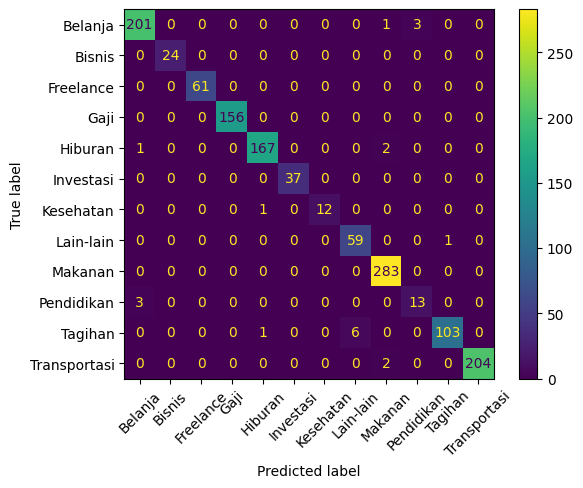

In [ ]:
# Evaluasi
print("=== Laporan Klasifikasi ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.show()

In [ ]:
# Fungsi prediksi interaktif
def prediksi_kategori_interaktif():
    deskripsi_baru = input("Masukkan deskripsi transaksi: ")
    deskripsi_baru = clean_text(deskripsi_baru)
    vektor = vectorizer.transform([deskripsi_baru])
    hasil = model.predict(vektor)
    return le.inverse_transform(hasil)[0]

# Contoh panggil fungsi
kategori = prediksi_kategori_interaktif()
print(f"Kategori transaksi: {kategori}")

Masukkan deskripsi transaksi: Tiket pesawat di ATM BRI
Kategori transaksi: Transportasi


In [ ]:
# Gabungkan semua ke dictionary
model_bundle = {
    'model': model,
    'vectorizer': vectorizer,
    'label_encoder': le
}

# Simpan dictionary ke satu file .joblib
joblib.dump(model_bundle, 'model_klasifikasi_transaksi.joblib')


['model_klasifikasi_transaksi.joblib']

In [ ]:
import sys
import sklearn
import imblearn
import nltk
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import joblib
import Sastrawi

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Imbalanced-learn (imblearn):", imblearn.__version__)
print("NLTK:", nltk.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Joblib:", joblib.__version__)


Python: 3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
Imbalanced-learn (imblearn): 0.13.0
NLTK: 3.9.1
Matplotlib: 3.10.0
Seaborn: 0.13.2
Joblib: 1.5.0


In [ ]:
import importlib.metadata
print("Sastrawi:", importlib.metadata.version('Sastrawi'))


Sastrawi: 1.0.1
